# Quantum Channel Baseline Comparison

This notebook provides a tutorial-style overview of several quantum channel
models implemented in `quantum_comm_sim.channels`. For each channel, we:

- Build a simple QPSK transmitter/receiver chain.
- Send random symbols through the channel.
- Compute bit error rate (BER) and symbol error rate (SER).
- Visualize pre- and post-channel constellations to illustrate the impact of
  different impairments.

Academic References:
  - Nielsen, M.A. & Chuang, I.L., Quantum Computation and Quantum Information,
    Cambridge University Press, 2010. Ch. 8 (Quantum channels).
  - Bennett, C.H. et al., Capacities of quantum erasure channels,
    Phys. Rev. Lett., 78(16), 3217, 1997.
  - Giovannetti, V. et al., Bosonic Gaussian channels, arXiv:quant-ph/0404050, 2004.
  - Jurado-Navas, A. et al., A unified statistical model for Malaga distributed optical
    scattering communications, Optics Communications, 468, 126204, 2020.
  - Gordon, J.P. & Kogelnik, H., PMD fundamentals: polarization mode dispersion in optical fibers,
    PNAS, 97(9), 4541-4550, 2000.


## Interpreting the channel effects

For each channel below we run the same QPSK transmit/receive chain and plot
pre- and post-channel constellations.

- **Depolarizing channel**: shrinks Bloch vectors toward the origin.
  In the constellation, RX points move radially inward compared to TX.
- **Dephasing channel**: suppresses off-diagonal density-matrix elements.
  In the constellation, points move horizontally toward the vertical axis
  (in-phase component decays, quadrature stays approximately fixed).
- **Erasure channel**: with probability *p* the symbol is replaced by an
  erasure state; averaged over many symbols this appears as a uniform
  shrink of the constellation radius.
- **Bosonic loss channel**: attenuates and adds thermal noise in a
  discretized Gaussian-loss model. In this baseline we use a simple
  2x2 surrogate so that increasing loss (3 dB ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 6 dB) produces a
  stronger radial shrink in the constellation.
- **Turbulence channel (MÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡laga)**: models log-normal-like irradiance
  fluctuations. In the constellation, weak turbulence causes mild radial
  jitter of the points, while strong turbulence leads to pronounced
  radial spread and occasional deep fades toward the origin.
- **PMD channel**: applies a random 2x2 unitary rotation (Jones matrix)
  to the polarization state. For a static PMD toy model this appears as
  a rotation of the QPSK points on the Bloch plane without changing
  their radius.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from quantum_comm_sim.channels.depolarizing_channel import DepolarizingChannel
from quantum_comm_sim.channels.dephasing_channel import DephasingChannel
from quantum_comm_sim.channels.erasure_channel import ErasureChannel
from quantum_comm_sim.channels.bosonic_channel import BosonicChannel
from quantum_comm_sim.channels.turbulence_channel import TurbulenceChannel
from quantum_comm_sim.channels.pmd_channel import PMDChannel

from quantum_comm_sim.metrics.ber_ser import compute_ber, compute_ser
from quantum_comm_sim.transceiver.modulators import QPSKModulator
from quantum_comm_sim.transceiver.transmitter import Transmitter
from quantum_comm_sim.transceiver.receiver import Receiver
from quantum_comm_sim.transceiver.detectors import PrettyGoodMeasurementDetector
from quantum_comm_sim.utils.visualization import plot_bloch_spheres, plot_constellation

# Results directories (match other experiments)
ROOT = os.path.dirname(os.path.dirname(__file__)) if '__file__' in globals() else os.path.join(os.getcwd(), '..')
RESULTS_ROOT = os.path.join(ROOT, 'results')
DATA_DIR = os.path.join(RESULTS_ROOT, 'data')
FIG_DIR = os.path.join(RESULTS_ROOT, 'figures')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
def build_chain(dim=2):
    mod = QPSKModulator(dim=dim)
    det = PrettyGoodMeasurementDetector(
        mod.reference_states(),
        labels=mod.symbol_alphabet(),
    )
    tx = Transmitter(modulator=mod)
    rx = Receiver(detector=det)
    return tx, rx


# Channel configurations for baseline and tutorial
def get_channel_configs():
    """Return tutorial channel configurations.


    Uses signatures consistent with the implemented channel models.
    QuaternionPMDChannel is excluded here because it does not implement
    the BaseChannel.apply API used by the transmitter/receiver baseline sweep.
    """
    return {
        "depolarizing_p01": lambda: DepolarizingChannel(p=0.1),
        "depolarizing_p05": lambda: DepolarizingChannel(p=0.5),
        "dephasing_p05": lambda: DephasingChannel(p=0.5),
        "erasure_p05": lambda: ErasureChannel(p=0.5),
        "bosonic_loss3db": lambda: BosonicChannel(dim=2, loss_db=3.0, noise_factor=0.05),
        "bosonic_loss6db": lambda: BosonicChannel(dim=2, loss_db=6.0, noise_factor=0.10),
        "turbulence_weak": lambda: TurbulenceChannel(turbulence_model="malaga", alpha=2.5, beta=2.0),
        "turbulence_strong": lambda: TurbulenceChannel(turbulence_model="malaga", alpha=1.2, beta=1.1),
        "pmd_static": lambda: PMDChannel(dgd_mean_ps=10.0, num_sections=10),
    }

In [3]:
def run_simulation(channel, num_symbols=4000, seed=42):
    np.random.seed(seed)
    tx, rx = build_chain(dim=2)

    tx_symbols = np.random.randint(0, 4, size=num_symbols)
    tx_states = tx.transmit(tx_symbols)
    rx_states = np.array([channel.apply(state) for state in tx_states])
    rx_symbols = rx.receive(rx_states)

    tx_bits = tx.modulator.symbols_to_bits(tx_symbols).reshape(-1)
    rx_bits = tx.modulator.symbols_to_bits(rx_symbols).reshape(-1)
    ber = compute_ber(tx_bits, rx_bits)
    ser = compute_ser(tx_symbols, rx_symbols)

    return ber, ser, tx_states, rx_states, tx_symbols

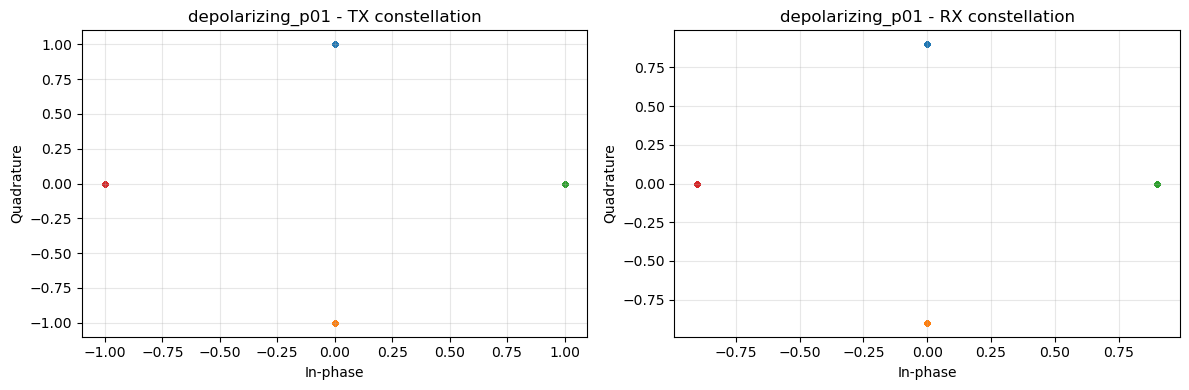

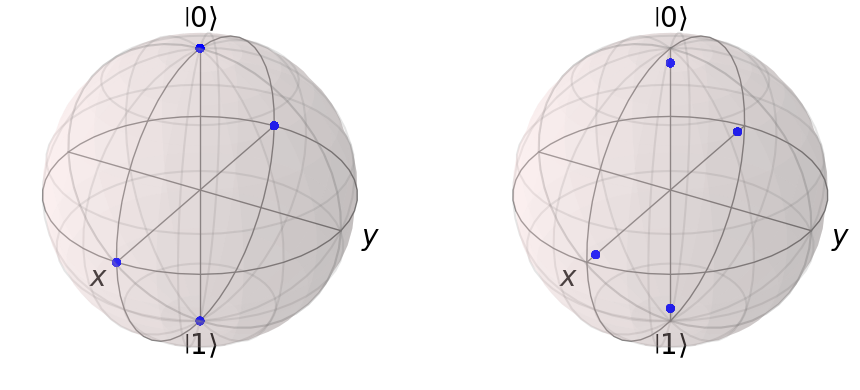

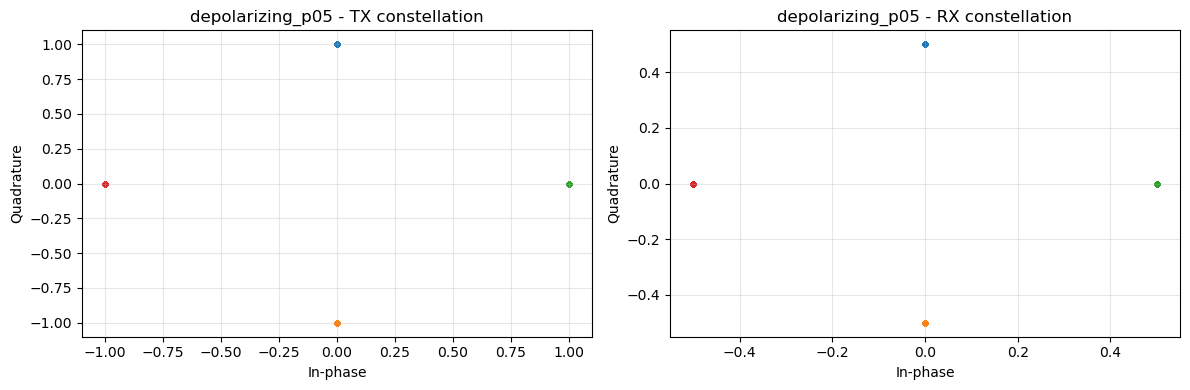

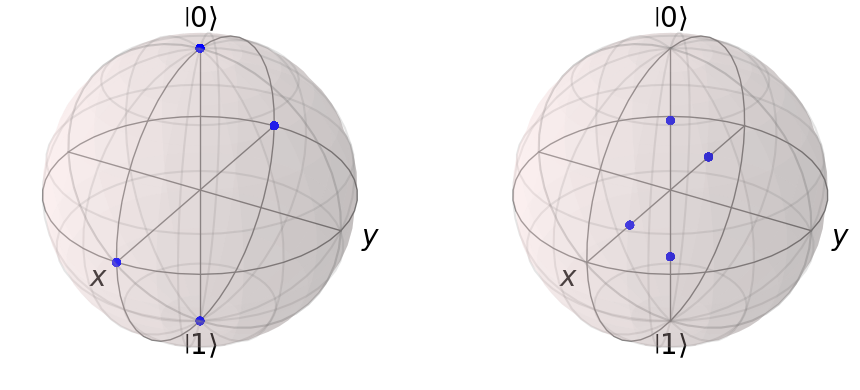

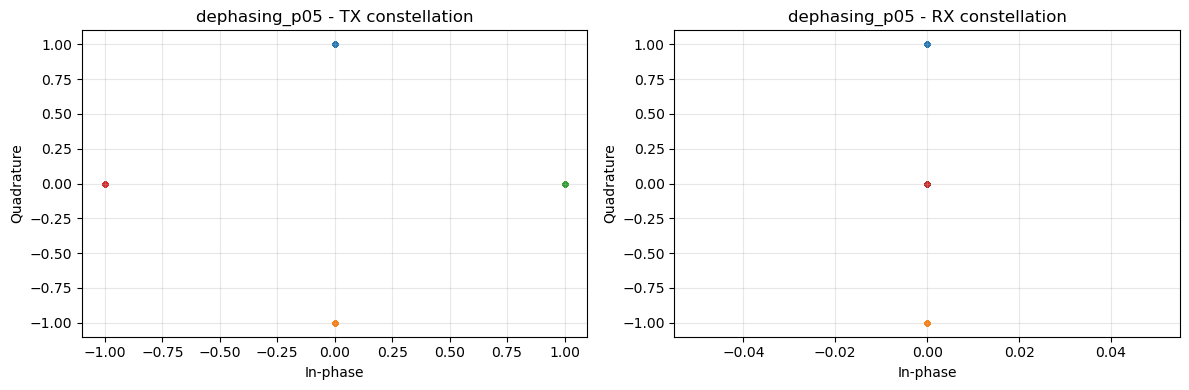

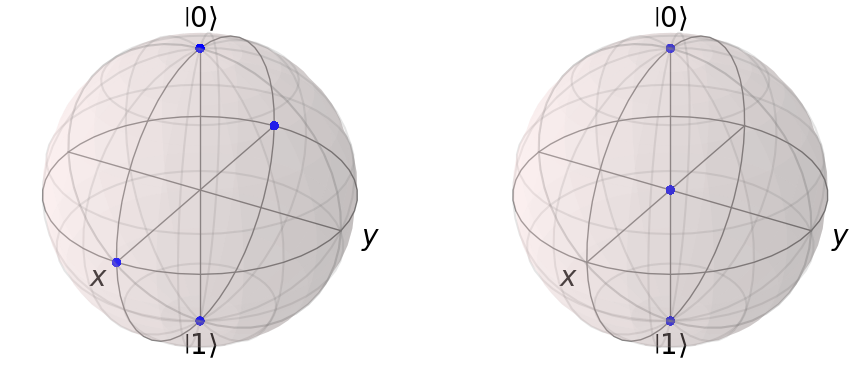

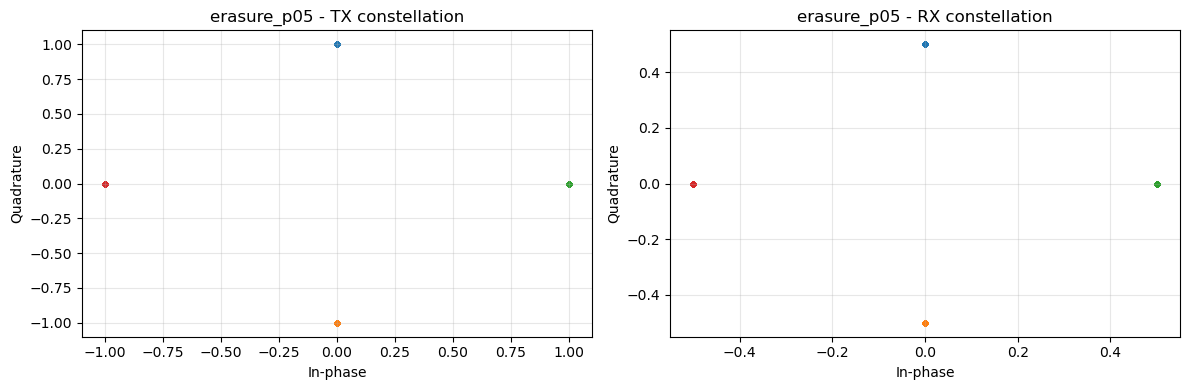

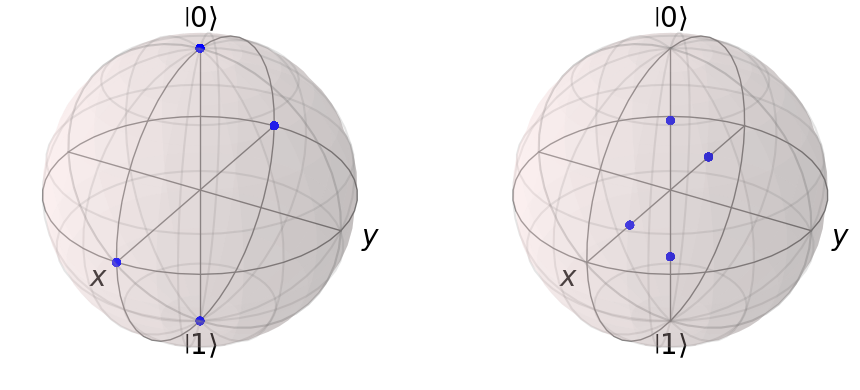

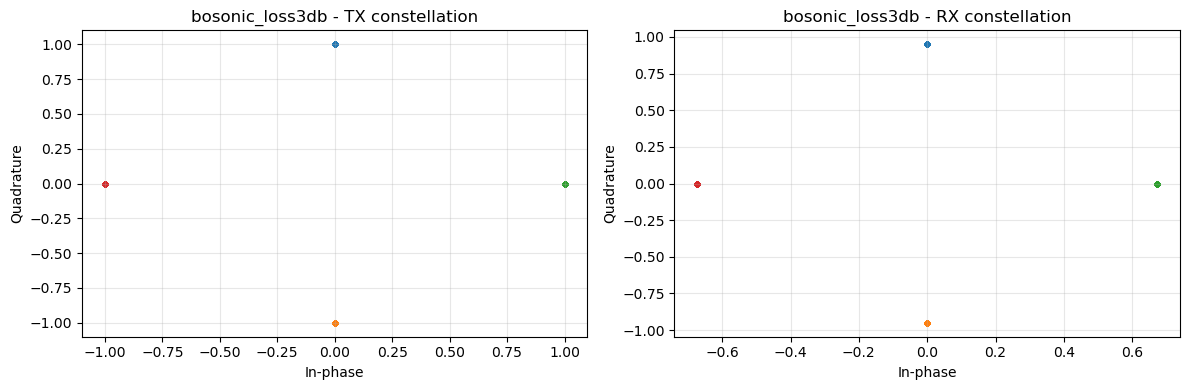

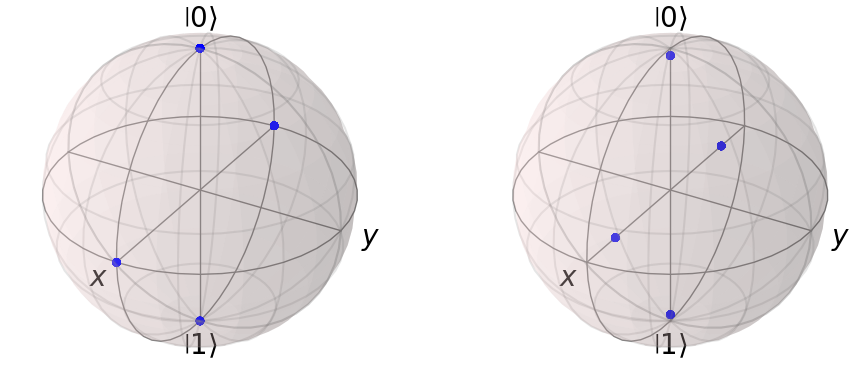

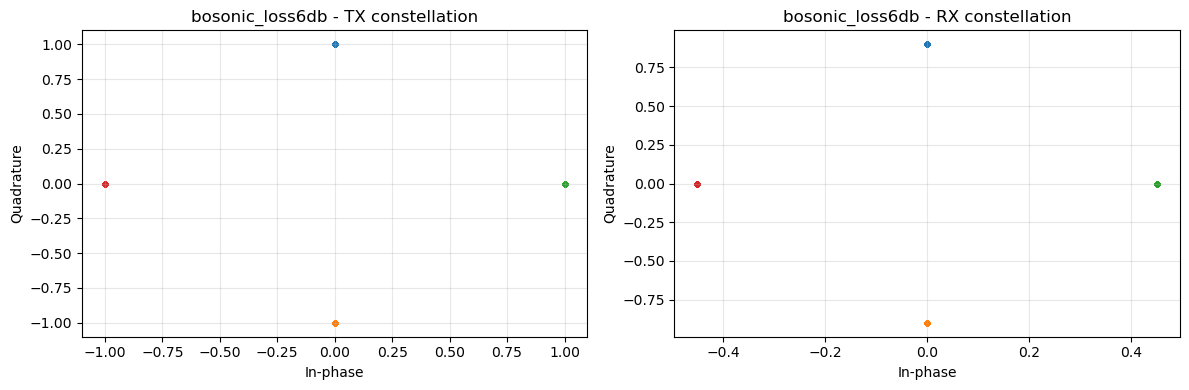

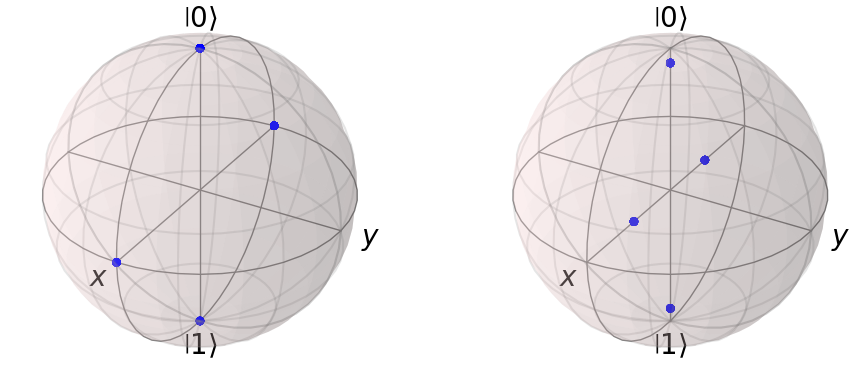

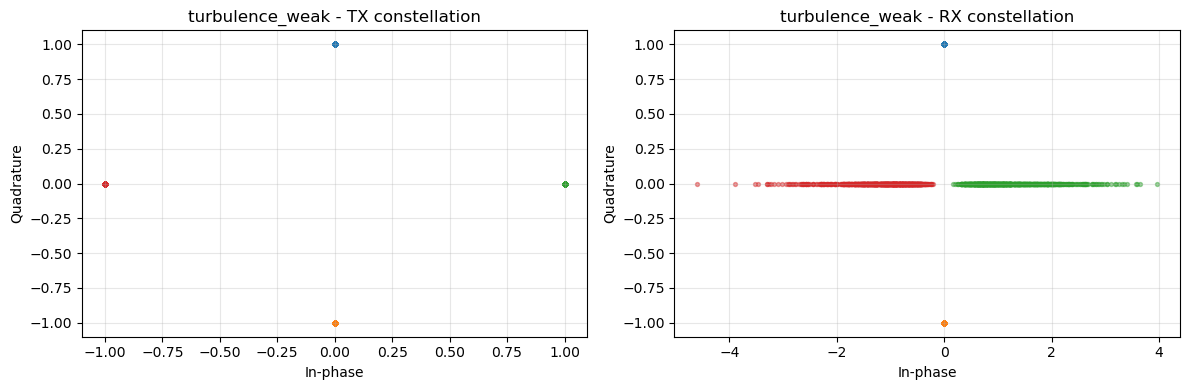

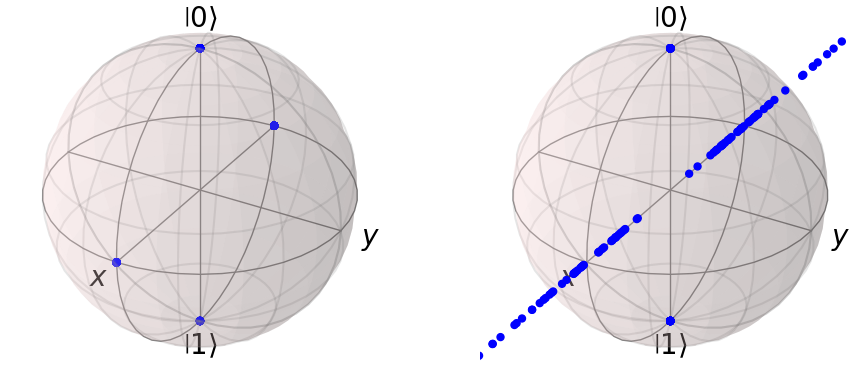

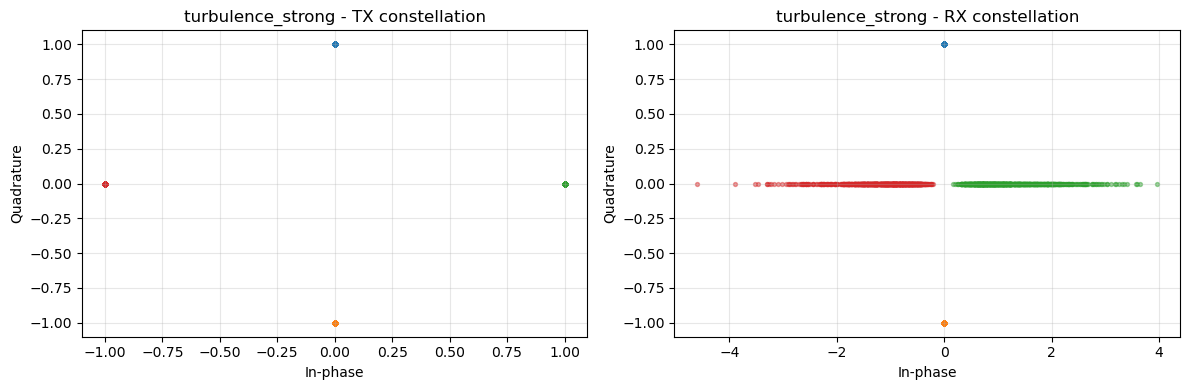

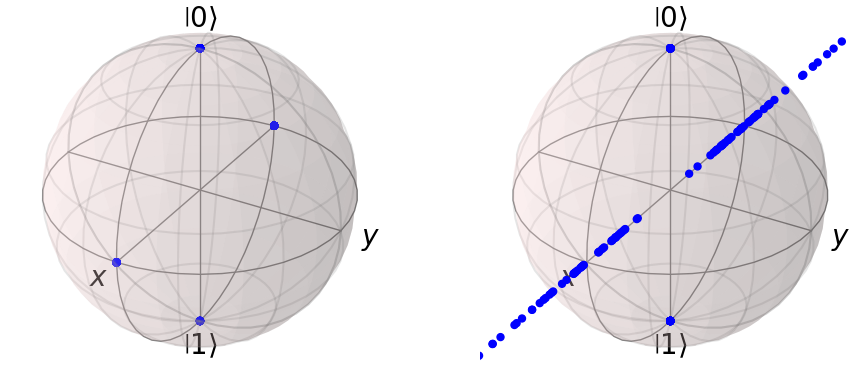

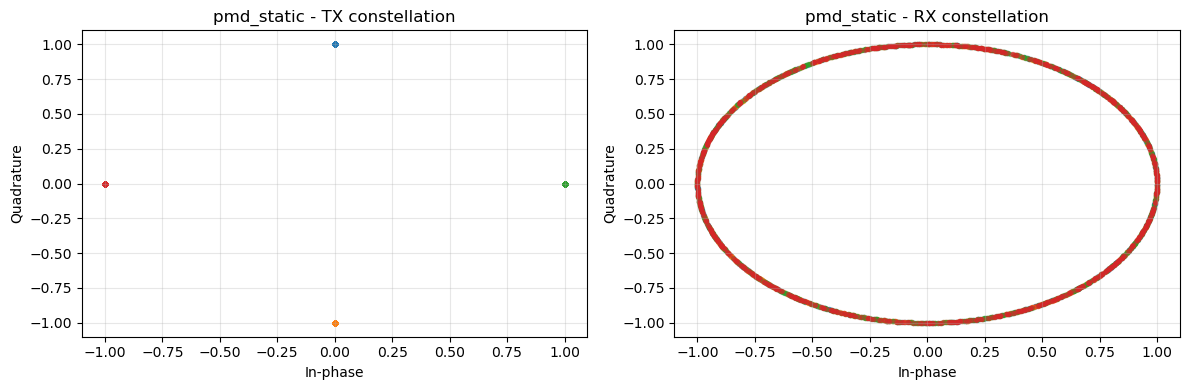

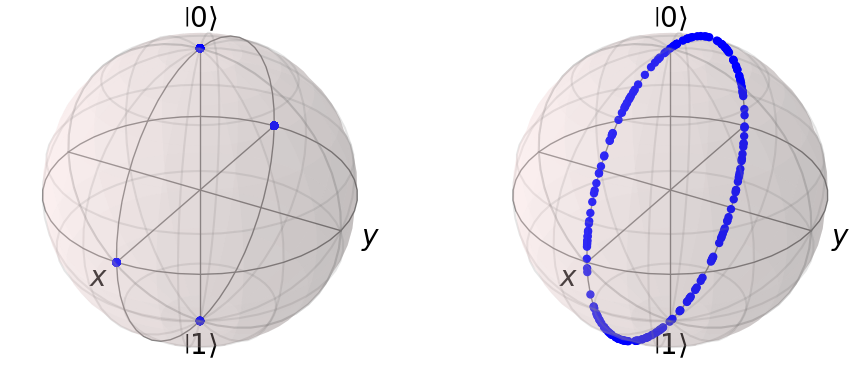

[depolarizing_p01    ] BER=0.0000e+00, SER=0.0000e+00
[depolarizing_p05    ] BER=0.0000e+00, SER=0.0000e+00
[erasure_p05         ] BER=0.0000e+00, SER=0.0000e+00
[bosonic_loss3db     ] BER=0.0000e+00, SER=0.0000e+00
[bosonic_loss6db     ] BER=0.0000e+00, SER=0.0000e+00
[turbulence_weak     ] BER=0.0000e+00, SER=0.0000e+00
[turbulence_strong   ] BER=0.0000e+00, SER=0.0000e+00
[dephasing_p05       ] BER=3.8338e-01, SER=5.1175e-01
[pmd_static          ] BER=5.0100e-01, SER=7.4850e-01
Saved summary to c:\Users\z642291\Downloads\workspace\quantum-comm-sim\notebooks\..\results\data\quantum_channel_baseline_summary.txt


In [4]:
# Run sweep and visualize a few representative channels
channel_configs = get_channel_configs()

summary = []

for name, ch_fn in channel_configs.items():
    ch = ch_fn()
    ber, ser, tx_states, rx_states, tx_labels = run_simulation(
        ch, num_symbols=4000, seed=123
    )
    summary.append((name, ber, ser))

    # Constellation diagrams (TX / RX)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_constellation(axes[0], tx_states, f"{name} - TX constellation",
                       labels=tx_labels)
    plot_constellation(axes[1], rx_states, f"{name} - RX constellation",
                       labels=tx_labels)
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f"constellation_{name}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()

    # Bloch spheres (QuTiP) instead of Bloch-plane subplot
    plot_bloch_spheres(tx_states, rx_states, name)

# Sort and store summary
summary = sorted(summary, key=lambda x: x[1])
for name, ber, ser in summary:
    print(f"[{name:20s}] BER={ber:.4e}, SER={ser:.4e}")

summary_path = os.path.join(DATA_DIR, "quantum_channel_baseline_summary.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("# name, BER, SER\n")
    for name, ber, ser in summary:
        f.write(f"{name}, {ber:.6e}, {ser:.6e}\n")

print(f"Saved summary to {summary_path}")